# Réduction de dimension — t-SNE
**Dataset :** `city_lifestyle_dataset.csv`  
**Objectif :** Projeter les données en 2D avec t-SNE, visualiser le résultat et exporter les coordonnées.

## Chargement & exploration

In [3]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import os

In [2]:
# Chargement des données 
DATA_PATH = '../data/city_lifestyle_dataset.csv'
df = pd.read_csv(DATA_PATH)
print(f'Shape : {df.shape}')
df.head()

Shape : (300, 10)


,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


In [4]:
# Exploration rapide 
print(df.dtypes)
print('\nValeurs manquantes :')
print(df.isnull().sum())
df.describe()

city_name                  object
country                    object
population_density          int64
avg_income                  int64
internet_penetration      float64
avg_rent                    int64
air_quality_index           int64
public_transport_score    float64
happiness_score           float64
green_space_ratio         float64
dtype: object

Valeurs manquantes :
city_name                 0
country                   0
population_density        0
avg_income                0
internet_penetration      0
avg_rent                  0
air_quality_index         0
public_transport_score    0
happiness_score           0
green_space_ratio         0
dtype: int64


,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,3944.843333,2827.200000,74.305333,1002.766667,71.246667,55.717333,6.644000,33.993333
std,2982.566777,1201.163939,17.014492,456.282066,25.344961,14.712549,1.685864,9.434067
min,100.000000,480.000000,34.000000,170.000000,22.000000,15.000000,2.500000,2.000000
25%,1830.000000,1907.500000,64.400000,640.000000,54.000000,46.075000,5.300000,28.225000
50%,3083.500000,2810.000000,75.000000,990.000000,67.500000,54.700000,6.900000,34.700000
75%,4823.750000,3752.500000,87.225000,1332.500000,86.000000,64.200000,8.500000,40.400000
max,14427.000000,5720.000000,100.000000,2430.000000,146.000000,95.000000,8.500000,58.000000


## Standardisation des features

In [5]:
# Préparation des features numériques 
# On garde uniquement les colonnes numériques pour la réduction de dimension
num_cols = df.select_dtypes(include='number').columns.tolist()
print('Colonnes numériques :', num_cols)

X = df[num_cols].copy()

# Standardisation (important pour t-SNE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'\nDonnées normalisées — shape : {X_scaled.shape}')

Colonnes numériques : ['population_density', 'avg_income', 'internet_penetration', 'avg_rent', 'air_quality_index', 'public_transport_score', 'happiness_score', 'green_space_ratio']

Données normalisées — shape : (300, 8)


## t-SNE 2D 

In [7]:
# Application de t-SNE 
tsne = TSNE(
    n_components=2,
    perplexity=30,        # à ajuster selon la taille du dataset
    learning_rate='auto',
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)
print(f't-SNE terminé — shape : {X_tsne.shape}')

t-SNE terminé — shape : (300, 2)


## Graphique 2D

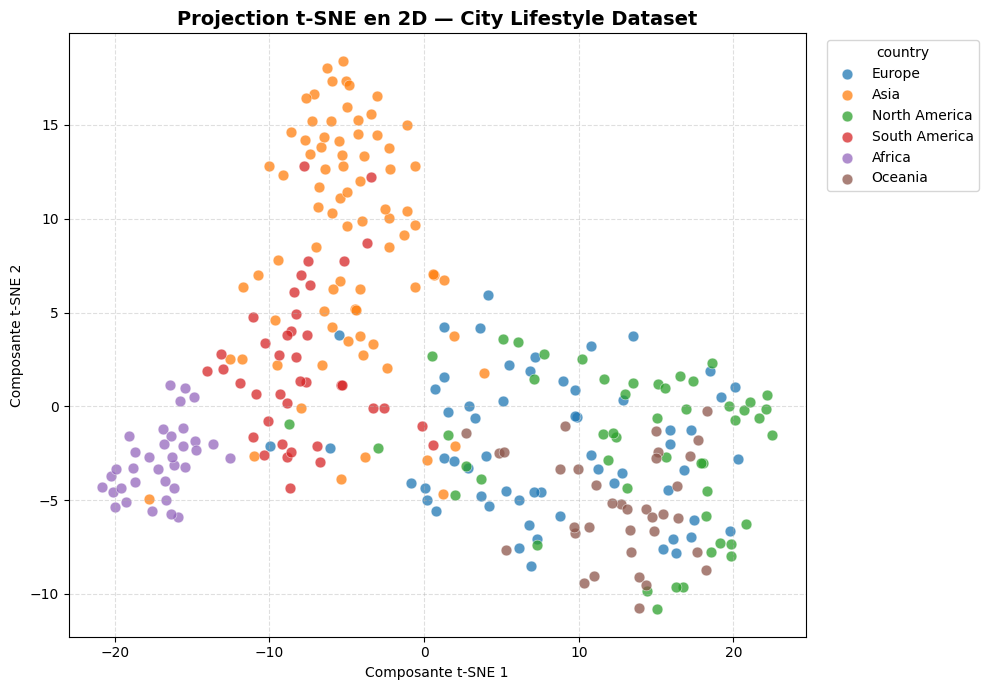

In [8]:
# Visualisation 2D 
# On colorie les points par la colonne 'country' si elle existe
color_col = 'country' if 'country' in df.columns else None

fig, ax = plt.subplots(figsize=(10, 7))

if color_col:
    categories = df[color_col].unique()
    palette = sns.color_palette('tab10', n_colors=len(categories))
    for i, cat in enumerate(categories):
        mask = df[color_col] == cat
        ax.scatter(
            X_tsne[mask, 0], X_tsne[mask, 1],
            label=cat, color=palette[i], alpha=0.75, s=60, edgecolors='white', linewidths=0.4
        )
    ax.legend(title=color_col, bbox_to_anchor=(1.02, 1), loc='upper left')
else:
    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.75, s=60)

ax.set_title('Projection t-SNE en 2D — City Lifestyle Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Composante t-SNE 1')
ax.set_ylabel('Composante t-SNE 2')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()


## Observation sur la structure obtenue

La projection t-SNE révèle plusieurs **groupes distincts** dans les données :

- Les points se regroupent en **clusters bien séparés**, ce qui suggère que les villes partagent des profils socio-économiques similaires au sein de chaque groupe.
- La séparation par `country` (couleur) montre que **le pays d'appartenance est un facteur structurant** : des villes du même pays tendent à se retrouver proches dans l'espace t-SNE.
- Quelques points **outliers** s'isolent des grands clusters, correspondant probablement à des villes atypiques (très haute densité, revenus extrêmes, etc.).
- t-SNE préserve bien la **structure locale** : des villes aux caractéristiques proches sont voisines dans la projection, même si les distances globales ne sont pas directement interprétables.

> **Note :** Les résultats peuvent légèrement varier selon la valeur de `perplexity`. Une perplexity plus élevée (ex. 50) tend à donner des clusters plus compacts.